In [2]:
import os, sys

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pymc as pm

# Add src to path
sys.path.append(os.path.abspath('../src'))
from data.database import get_car_items

    mileage  age_in_days
0  2.975597     1.959697


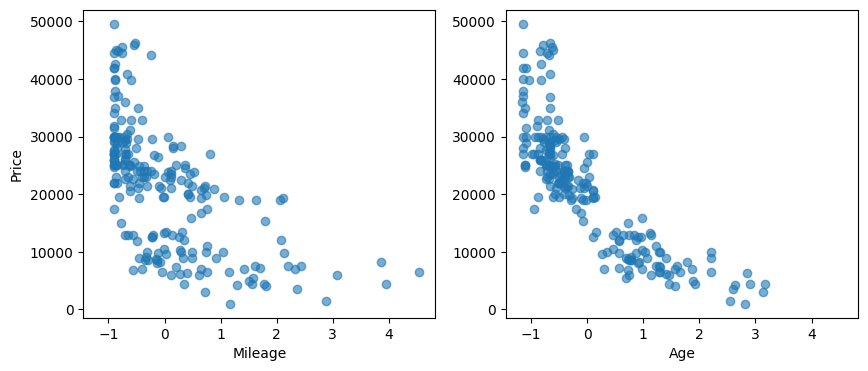

In [6]:
LUDOSPACE = ['RENAULT_Kangoo', 'TOYOTA_PROACE CITY Verso', 'PEUGEOT_Rifter', 'CITROEN_Berlingo', 'OPEL_Combo', 'OPEL_Combo Life', 'FIAT_Doblo', 'MERCEDES-BENZ_EQT']

full_raw_dataset = get_car_items(models=LUDOSPACE)
full_raw_dataset = full_raw_dataset.dropna(subset=['price', 'mileage', 'age_in_days'])

# remove cars with only 2, 3 or 4 seats
full_raw_dataset = full_raw_dataset[~full_raw_dataset['seats'].astype(str).isin(['2', '3', '4'])]

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))

class Scaler:
    def fit(self, X):
        self.mean = X.mean()
        self.std = X.std()
        return self

    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)
    
    def inverse_transform(self, X):
        return X * self.std + self.mean
    

# scale features

scaler = Scaler()
X = full_raw_dataset[['mileage', 'age_in_days']]
y = full_raw_dataset['price']
X_scaled = scaler.fit_transform(X)

print(scaler.transform(pd.DataFrame({'mileage': [100000], 'age_in_days': [3650]})))

axes[0].scatter(X_scaled['mileage'], y, alpha=0.6)
axes[1].scatter(X_scaled['age_in_days'], y, alpha=0.6)
axes[0].set_ylabel("Price")
axes[0].set_xlabel("Mileage")
axes[1].set_xlabel("Age")

plt.show()

In [41]:
non_scaled_dataset = full_raw_dataset.copy()

with pm.Model() as basic_model:
    # Priors for unknown model parameters
    mileage_factor = pm.Normal("mileage_factor", mu=-0.1, sigma=0.05)    # -€0.10 per km
    age_factor = pm.Normal("age_factor", mu=-5, sigma=2)                 # -€5 per day
    sigma = pm.HalfNormal("sigma", sigma=5000)                           # Realistic price variance
    price0 = pm.Normal("price0", mu=35000, sigma=5000)                   # Base price


    # Expected value of outcome
    estimated_price = pm.Deterministic("estimated_price", price0 + mileage_factor * non_scaled_dataset['mileage'] + age_factor * non_scaled_dataset['age_in_days'])

    # Add the likelihood (observation model)
    Y_obs = pm.Normal("price_obs", mu=estimated_price, sigma=sigma, observed=non_scaled_dataset['price'])

In [ ]:
# Sample from prior predictive distribution
with basic_model:
    prior_predictive = pm.sample_prior_predictive(samples=1000, random_seed=42)

Shape of estimated_price: (1000,)


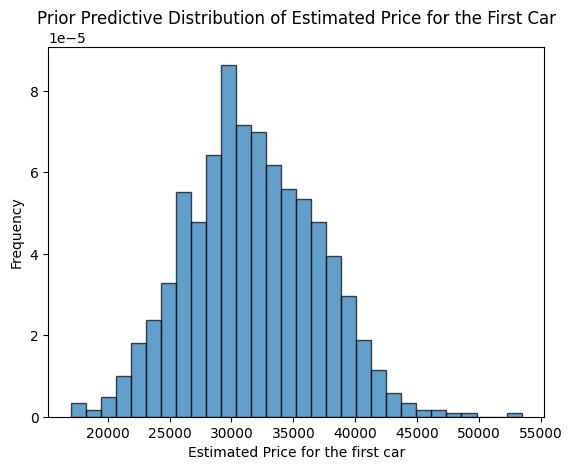

In [ ]:
# show how price behaves with defined priors, plot an histogram of prices

# check the estimated price for the first car of the dataset - FIXED ACCESS
estimated_price_first_car = prior_predictive.prior['estimated_price'][0, :, 0]  # Shape (chain, samples, cars)

# Check the shape
print("Shape of estimated_price:", estimated_price_first_car.shape)

# show these estimated price on a histogram
plt.hist(estimated_price_first_car, bins=30, alpha=0.7, density=True, edgecolor='black')
plt.xlabel("Estimated Price for ")
plt.ylabel("Frequency")
plt.title("Prior Predictive Distribution of Estimated Price for the First Car")
plt.show()

In [ ]:

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("price_obs", mu=price_model, sigma=sigma, observed=non_scaled_dataset['price'])

    idata = pm.sample()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

array([[<Axes: title={'center': 'price0'}>,
        <Axes: title={'center': 'price0'}>],
       [<Axes: title={'center': 'mileage_factor'}>,
        <Axes: title={'center': 'mileage_factor'}>],
       [<Axes: title={'center': 'age_factor'}>,
        <Axes: title={'center': 'age_factor'}>],
       [<Axes: title={'center': 'price_model'}>,
        <Axes: title={'center': 'price_model'}>]], dtype=object)

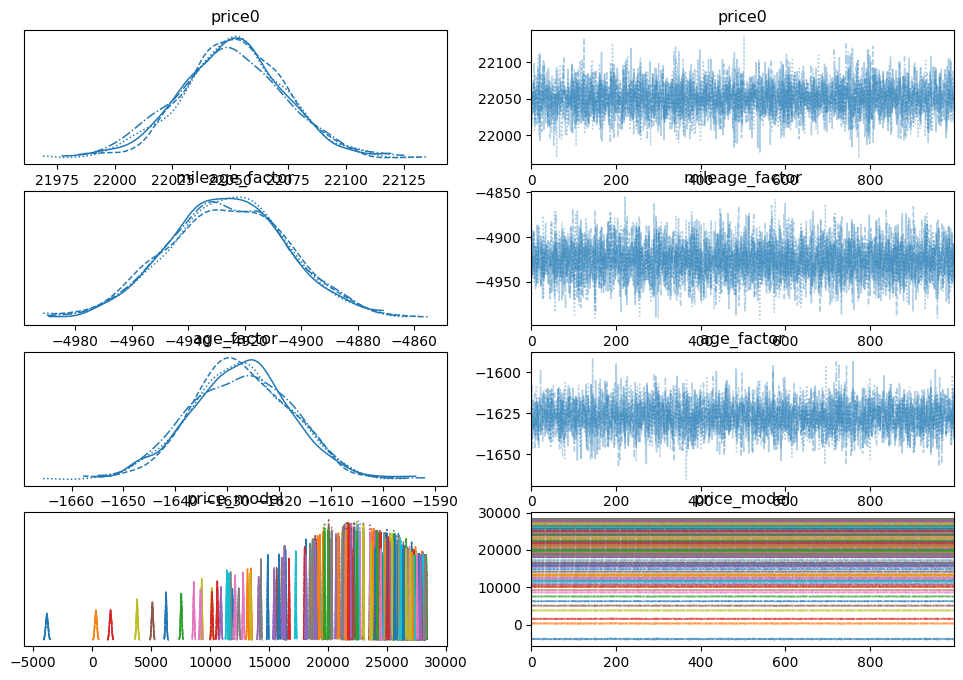

In [36]:
az.plot_trace(idata, var_names=["price0", "mileage_factor", "age_factor", "price_model"])

In [33]:
az.summary(idata, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mileage_factor,-4926.00,21.18,-4965.83,-4885.92,0.28,0.30,5843.56,3459.17,1.0
age_factor,-1627.37,9.61,-1645.09,-1609.26,0.14,0.13,4772.66,3362.02,1.0
price0,22050.96,22.53,22007.01,22091.98,0.30,0.39,5708.94,3142.74,1.0
sigma,332.80,0.52,331.88,333.82,0.01,0.01,5114.77,2933.24,1.0
price_model[0],18122.07,25.71,18071.88,18168.17,0.35,0.40,5457.57,3182.54,1.0
...,...,...,...,...,...,...,...,...,...
price_model[210],25641.66,25.08,25594.00,25688.25,0.32,0.41,6255.36,3268.78,1.0
price_model[211],20863.44,24.50,20817.64,20909.68,0.32,0.38,5928.76,3326.91,1.0
price_model[212],19983.06,24.38,19936.78,20028.44,0.32,0.38,5849.09,3141.94,1.0
price_model[213],21723.88,22.73,21680.73,21766.45,0.30,0.38,5823.97,3227.83,1.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

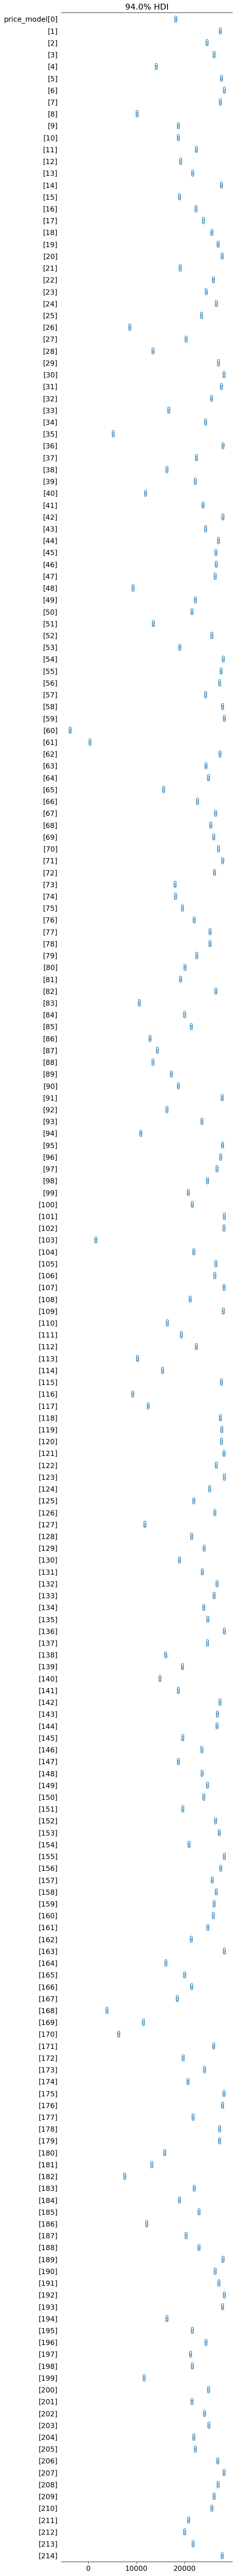

In [35]:
az.plot_forest(idata, var_names=["price_model"])

In [ ]:
import numpy as np
print(np.mean(idata.posterior['price0']))



In [ ]:
idata.posterior["Price_model"] = idata.posterior["price0"] + idata.posterior["mileage_factor"] * scaled['mileage'] + idata.posterior["age_factor"] * scaled['age_in_days']

_, ax = plt.subplots(figsize=(7, 7))
az.plot_lm(idata=idata, y="Price", num_samples=100, axes=ax, y_model="Price_model")
ax.set_title("Posterior predictive regression lines")
ax.set_xlabel("x");